# Rainbow option on SPX / SX5E / HSI: implied marginals + copula Monte Carlo

First multi-underlying exotic on the three vendor surfaces — one option valued end to
end, as the template for a future rainbow book. The payoff at expiry $T$ on notional $N$:

$$B \;=\; 50\%\cdot \mathrm{best}(P_{SPX},P_{SX5E}) \;+\; 30\%\cdot \mathrm{worst}(P_{SPX},P_{SX5E}) \;+\; 20\%\cdot P_{HSI},
\qquad P_i = S_i(T)/S_i(0)$$

$$\text{payoff} \;=\; N\cdot\min\!\big(\max(B-100\%,\,0),\;12\%\big)
\qquad\text{— a call spread on } B \text{, strikes } 100\%/112\%$$

We **sell** \$1M notional of the 1Y structure. The weights sum to 1 and max/min commute
with subtracting 1, so $B-1$ is exactly the ranked weighting of net returns — "strike
100%" is unambiguous. The cap is set wider than the single-index book's 110% because the
ranked basket prices cheaper; section 4 quantifies by how much.

Method (`vol_pca/rainbow.py`, deliberately simple per the study spec):

- **Marginals**: each index's risk-neutral 1Y distribution comes from its own surface by
  Breeden–Litzenberger — undiscounted calls $C(x)$ on a performance grid $x=K/S_0$
  through the project's bicubic pillar interpolant, $\mathbb{P}(X\le x) = 1 + C'(x)$,
  density $C''(x)$. Wings beyond the quoted 50–150 moneyness range continue with the
  smile's edge slope, exponentially tapered to a bounded level: the pricing grid's flat
  clamp kinks $\sigma(x)$ where the put wing still has vega — teleporting ~2–3% of
  probability mass and biasing the recovered mean ~30bp under the forward — while an
  untapered slope violates Lee's moment bound on rising call wings (HSI's rises).
- **Dependence**: a Gaussian copula with one constant historical correlation matrix,
  estimated on 5-day overlapping log returns — same-calendar-day returns understate
  cross-region co-movement because HSI and SX5E close hours before SPX.
- **No FX / quanto adjustment**, and USD discounting of the composite payoff, per the
  spec: each marginal lives under its own forward measure, glued directly.
- Rainbows are only evaluated on dates where **all three surfaces quote**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vol_pca import load_surfaces
from vol_pca.rainbow import (K_HI, K_LO, NOTIONAL, bs_implied_vol, call_spread_payoff,
                             date_index, historical_corr, implied_marginal,
                             marginal_call_spread, price_rainbow,
                             price_rainbow_quad, rainbow_basket,
                             sample_performances, spot_panel)

C_IDX = {"SPX": "#2a78d6", "SX5E": "#2e9e77", "HSI": "#b7852e"}
C_BASKET, C_TAIL, C_INK, C_GRAY = "#8a5cd0", "#e34948", "#0b0b0b", "#898781"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})

NAMES = list(C_IDX)
sds = {n: load_surfaces(f"{n}_volSurface.csv") for n in NAMES}
for n, sd in sds.items():
    print(f"{n:4s}: {len(sd):,} dates {sd.dates[0]} .. {sd.dates[-1]}  "
          f"(dropped {sd.n_dupes_dropped} dup rows, repaired {sd.n_wing_repaired} wing rows)")
spots = spot_panel(sds)
print(f"joint: {len(spots):,} dates where all three surfaces quote "
      f"({spots.index[0].date()} .. {spots.index[-1].date()})")

SPX : 1,969 dates 2018-12-27 .. 2026-07-31  (dropped 221 dup rows, repaired 6 wing rows)
SX5E: 1,970 dates 2018-12-27 .. 2026-07-31  (dropped 221 dup rows, repaired 0 wing rows)
HSI : 1,971 dates 2018-12-27 .. 2026-07-31  (dropped 204 dup rows, repaired 0 wing rows)
joint: 1,969 dates where all three surfaces quote (2018-12-27 .. 2026-07-31)


## 1. The three 1Y marginals off the smile

`implied_marginal` builds, per index: undiscounted calls on a log-spaced performance
grid, the CDF, the Breeden–Litzenberger density, and a quantile function for sampling.
Two sanity checks are asserted below: the recovered mean must reproduce the model-free
forward ratio (it does, to well under a basis point on all three), and the density must
integrate to 1. Character of the three: **SPX** carries the steepest skew (fattest
crash tail) and by far the richest forward (~+3.7% carry at 1Y — the rainbow's ITM-ness
lives mostly here); **SX5E** is a milder copy; **HSI** is the widest at the money but
with a much flatter, more symmetric smile — its call wing actually turns *up*.

In [2]:
TTM = 1.0
val = spots.index[-1]
idx = {n: date_index(sds[n], np.datetime64(val, "D")) for n in NAMES}
margs = {n: implied_marginal(sds[n], idx[n], TTM) for n in NAMES}
marg_list = [margs[n] for n in NAMES]
df_usd = float(sds["SPX"].discount(idx["SPX"], TTM))

snap = pd.DataFrame({n: {
    "spot": sds[n].spot[idx[n]],
    "fwd / spot": m.fwd_ratio,
    "ATM 1Y vol": np.interp(1.0, m.x, m.vols),
    "90-110 skew": np.interp(0.9, m.x, m.vols) - np.interp(1.1, m.x, m.vols),
    "E[X] - fwd (bp)": (m.mean - m.fwd_ratio) * 1e4,
} for n, m in margs.items()})
print(f"valuation date {val.date()}, expiry T = {TTM:.0f}Y, "
      f"USD discount factor {df_usd:.4f} (1Y zero {-np.log(df_usd) / TTM:.2%})")
print(snap.round(4).to_string())

for n, m in margs.items():
    assert abs(m.mean / m.fwd_ratio - 1.0) < 1e-3, n            # mean == forward
    assert abs(np.trapezoid(m.pdf, m.x) - 1.0) < 1e-3, n        # unit mass

valuation date 2026-07-31, expiry T = 1Y, USD discount factor 0.9604 (1Y zero 4.04%)
                       SPX       SX5E         HSI
spot             7489.7200  6358.0100  25884.4300
fwd / spot          1.0375     1.0062      1.0044
ATM 1Y vol          0.1807     0.1741      0.2064
90-110 skew         0.0673     0.0498      0.0211
E[X] - fwd (bp)     0.0766    -0.2562      0.0605


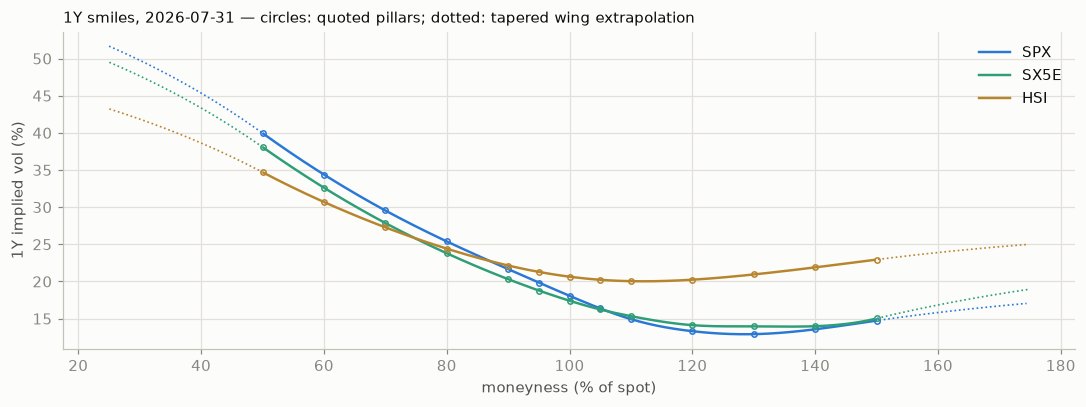

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for n, m in margs.items():
    mon = 100.0 * m.x
    pil = sds[n].moneyness
    ax.plot(mon[(mon >= 50) & (mon <= 150)], 100 * m.vols[(mon >= 50) & (mon <= 150)],
            color=C_IDX[n], lw=1.6, label=n)
    for sel in ((mon >= 25) & (mon < 50), (mon > 150) & (mon <= 175)):
        ax.plot(mon[sel], 100 * m.vols[sel], color=C_IDX[n], lw=1.1, ls=":")
    ax.plot(pil, 100 * np.interp(pil / 100.0, m.x, m.vols), "o", ms=3.5,
            color=C_IDX[n], mfc="none")
ax.set_xlabel("moneyness (% of spot)")
ax.set_ylabel("1Y implied vol (%)")
ax.set_title(f"1Y smiles, {val.date()} — circles: quoted pillars; "
             "dotted: tapered wing extrapolation", loc="left", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

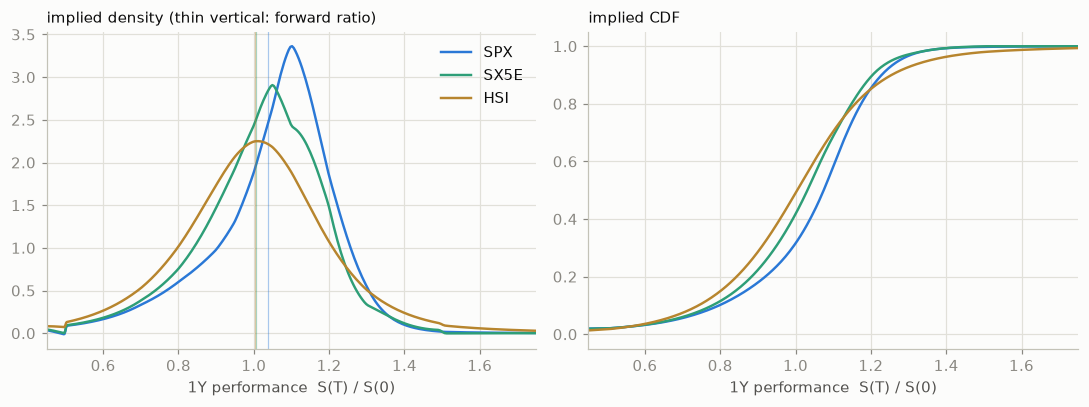

residual construction noise, min density (put-wing spline join): SPX -0.0118,  SX5E -0.0019,  HSI -0.0000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for n, m in margs.items():
    axes[0].plot(m.x, m.pdf, color=C_IDX[n], lw=1.6, label=n)
    axes[0].axvline(m.fwd_ratio, color=C_IDX[n], lw=0.8, alpha=0.4)
    axes[1].plot(m.x, m.cdf, color=C_IDX[n], lw=1.6)
for ax in axes:
    ax.set_xlim(0.45, 1.75)
    ax.set_xlabel("1Y performance  S(T) / S(0)")
axes[0].set_title("implied density (thin vertical: forward ratio)", loc="left", fontsize=10)
axes[1].set_title("implied CDF", loc="left", fontsize=10)
axes[0].legend()
plt.tight_layout()
plt.show()
print("residual construction noise, min density (put-wing spline join): "
      + ",  ".join(f"{n} {m.pdf.min():+.4f}" for n, m in margs.items()))

## 2. One constant correlation matrix

The three markets close hours apart (HSI at 08:00 UTC, SX5E mid-afternoon, SPX last),
so same-calendar-day return correlations are badly understated: SPX–HSI is **0.17
daily but 0.43 at five days** — and flat from there (0.44 at ten), which is the
asynchronous-close signature, not a horizon effect. The 5-day overlapping matrix is
therefore the constant used for pricing. The rolling view below shows what "constant"
sweeps under the rug — pairwise correlation swings through the sample — but section 4
shows this structure's price barely reacts to even ±0.2 correlation shifts, so the
crude estimate is not where the valuation risk sits.

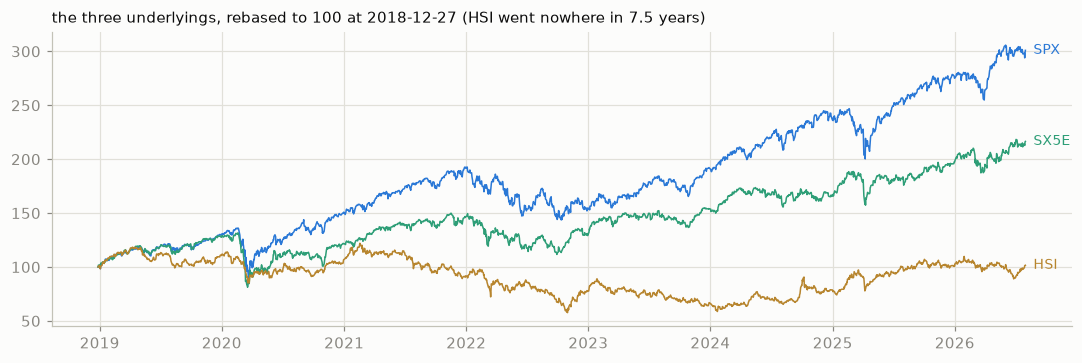

In [5]:
reb = 100.0 * spots / spots.iloc[0]
fig, ax = plt.subplots(figsize=(10, 3.4))
for n in NAMES:
    ax.plot(reb.index, reb[n], color=C_IDX[n], lw=1.0)
    ax.annotate(f"  {n}", (reb.index[-1], reb[n].iloc[-1]), color=C_IDX[n],
                fontsize=9, va="center")
ax.margins(x=0.05)
ax.set_title("the three underlyings, rebased to 100 at 2018-12-27 "
             "(HSI went nowhere in 7.5 years)", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

correlation of overlapping h-day log returns:
         1d                   5d                  10d              
        SPX   SX5E    HSI    SPX   SX5E    HSI    SPX   SX5E    HSI
SPX   1.000  0.568  0.169  1.000  0.751  0.429  1.000  0.793  0.442
SX5E  0.568  1.000  0.336  0.751  1.000  0.478  0.793  1.000  0.495
HSI   0.169  0.336  1.000  0.429  0.478  1.000  0.442  0.495  1.000


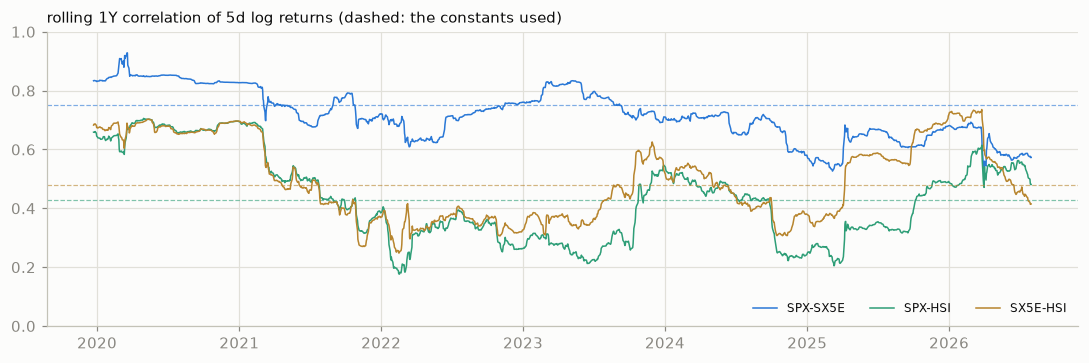

In [6]:
rets = {h: np.log(spots).diff(h).dropna() for h in (1, 5, 10)}
mats = {f"{h}d": rets[h].corr() for h in rets}
CORR = mats["5d"]
print("correlation of overlapping h-day log returns:")
print(pd.concat(mats, axis=1).round(3).to_string())
assert (historical_corr(spots, 5).to_numpy() == CORR.to_numpy()).all()

pairs = [("SPX", "SX5E"), ("SPX", "HSI"), ("SX5E", "HSI")]
fig, ax = plt.subplots(figsize=(10, 3.4))
for (a, b), c in zip(pairs, ("#2a78d6", "#2e9e77", "#b7852e")):
    rc = rets[5][a].rolling(252).corr(rets[5][b])
    ax.plot(rc.index, rc, lw=1.0, color=c, label=f"{a}-{b}")
    ax.axhline(CORR.loc[a, b], color=c, lw=0.8, ls="--", alpha=0.6)
ax.set_ylim(0, 1)
ax.legend(ncol=3, loc="lower right", fontsize=8)
ax.set_title("rolling 1Y correlation of 5d log returns (dashed: the constants used)",
             loc="left", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Gluing the marginals and simulating

Correlated standard normals → $\Phi$ → each marginal's quantile function; 400k paths,
fixed seed. The Gaussian copula preserves *rank* correlation of the normal scores, so
the Pearson correlation of the simulated (non-normal) performances comes out a touch
below the input matrix — printed below as a check, not a bug. Note what the copula
buys us: the marginals keep every detail of each smile (skew, fat tails, the forwards),
and only the dependence is an assumption.

Pearson correlation of simulated log performances (input in brackets):
  SPX-SX5E: 0.687  [0.751]
  SPX-HSI: 0.370  [0.429]
  SX5E-HSI: 0.423  [0.478]


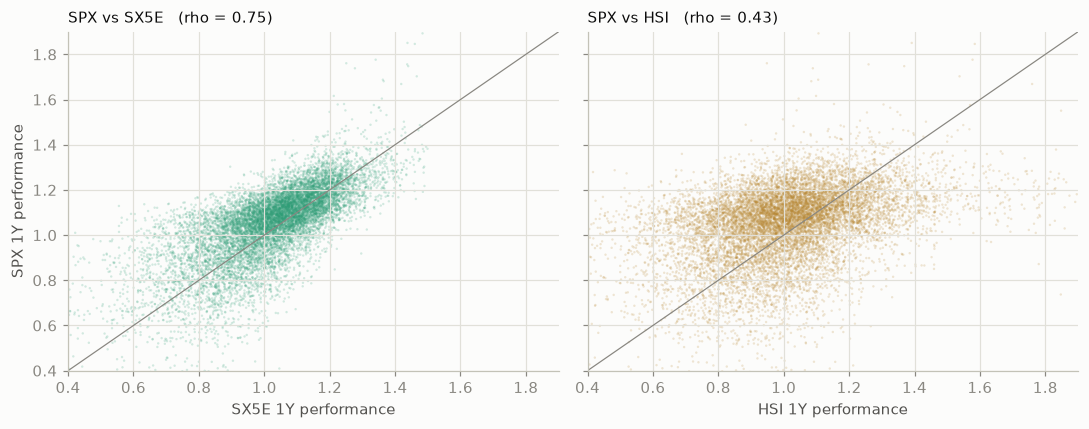

In [7]:
N_PATHS, SEED = 400_000, 0
perf = sample_performances(marg_list, CORR, N_PATHS, seed=SEED)
real = pd.DataFrame(np.corrcoef(np.log(perf).T), index=NAMES, columns=NAMES)
print("Pearson correlation of simulated log performances (input in brackets):")
for a, b in pairs:
    print(f"  {a}-{b}: {real.loc[a, b]:.3f}  [{CORR.loc[a, b]:.3f}]")

sub = np.random.default_rng(1).choice(N_PATHS, 12_000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), sharey=True)
for ax, other in zip(axes, ("SX5E", "HSI")):
    j = NAMES.index(other)
    ax.scatter(perf[sub, j], perf[sub, 0], s=2.5, alpha=0.2,
               color=C_IDX[other], edgecolors="none")
    ax.axline((1, 1), slope=1, color=C_GRAY, lw=0.8)
    ax.set_xlim(0.4, 1.9)
    ax.set_ylim(0.4, 1.9)
    ax.set_xlabel(f"{other} 1Y performance")
    ax.set_title(f"SPX vs {other}   (rho = {CORR.loc['SPX', other]:.2f})",
                 loc="left", fontsize=10)
axes[0].set_ylabel("SPX 1Y performance")
plt.tight_layout()
plt.show()

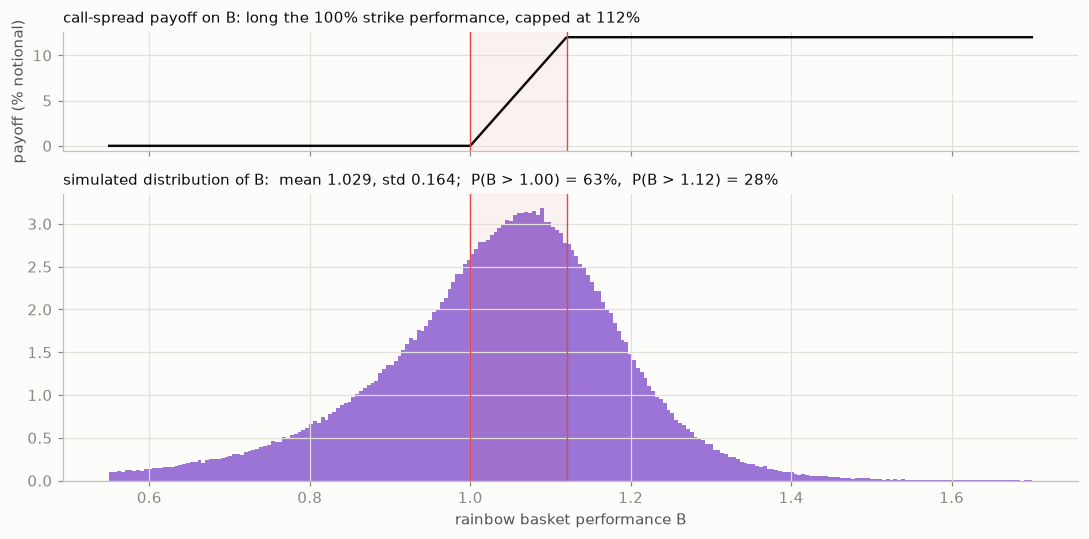

In [8]:
b = rainbow_basket(perf)               # columns already ordered SPX, SX5E, HSI
pay = call_spread_payoff(b)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 5.0), sharex=True,
                               height_ratios=[1, 2.4])
xs = np.linspace(0.55, 1.7, 601)
ax0.plot(xs, 100 * call_spread_payoff(xs), color=C_INK, lw=1.6)
ax0.set_ylabel("payoff (% notional)")
ax0.set_title("call-spread payoff on B: long the 100% strike performance, capped at 112%",
              loc="left", fontsize=10)
ax1.hist(b, bins=240, range=(0.55, 1.7), density=True, color=C_BASKET, alpha=0.85)
ax1.set_xlabel("rainbow basket performance B")
ax1.set_title(f"simulated distribution of B:  mean {b.mean():.3f}, std {b.std():.3f};  "
              f"P(B > {K_LO:.2f}) = {(b > K_LO).mean():.0%},  "
              f"P(B > {K_HI:.2f}) = {(b > K_HI).mean():.0%}", loc="left", fontsize=10)
for ax in (ax0, ax1):
    ax.axvspan(K_LO, K_HI, color=C_TAIL, alpha=0.05)
    ax.axvline(K_LO, color=C_TAIL, lw=0.9)
    ax.axvline(K_HI, color=C_TAIL, lw=0.9)
plt.tight_layout()
plt.show()

## 4. Price — and what the "cheaper structure" buys

Discount the average payoff on the USD curve. With 400k paths the standard error is
~\$80 on a ~\$53k premium, and the one-call wrapper `price_rainbow` (what a future
book loop would use) reproduces the cell-by-cell numbers exactly.

rainbow call spread 100%/112%, $1M notional, T = 1Y, sold 2026-07-31:
  fair value  $53,074   (5.307% of notional)   MC s.e. $79   [400,000 paths, seed 0]


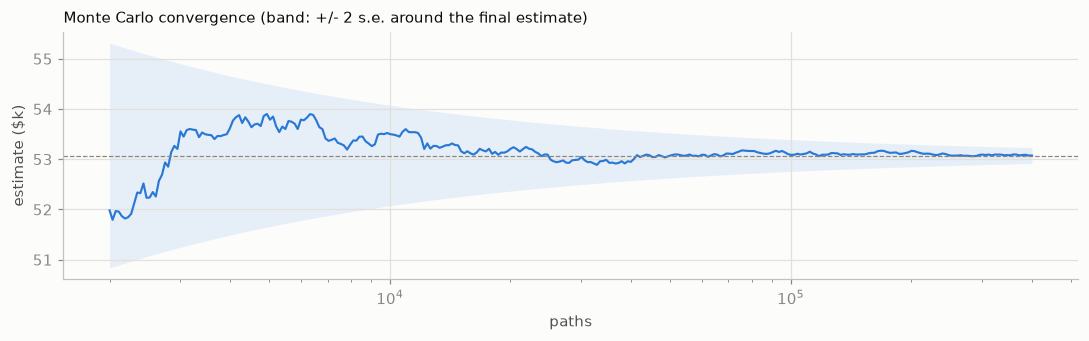

In [9]:
pv = df_usd * pay.mean() * NOTIONAL
se = df_usd * pay.std() / np.sqrt(N_PATHS) * NOTIONAL
print(f"rainbow call spread {K_LO:.0%}/{K_HI:.0%}, $1M notional, T = 1Y, "
      f"sold {val.date()}:")
print(f"  fair value  ${pv:,.0f}   ({pv / NOTIONAL:.3%} of notional)   "
      f"MC s.e. ${se:,.0f}   [{N_PATHS:,} paths, seed {SEED}]")
res = price_rainbow(marg_list, CORR, df_usd, n_paths=N_PATHS, seed=SEED)
assert np.isclose(res["pv"], pv) and np.isclose(res["se"], se)

ck = np.unique(np.geomspace(2_000, N_PATHS, 300).astype(int))
running = df_usd * np.cumsum(pay)[ck - 1] / ck * NOTIONAL
band = 2 * df_usd * pay.std() / np.sqrt(ck) * NOTIONAL
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.fill_between(ck, (pv - band) / 1e3, (pv + band) / 1e3, color="#2a78d6",
                alpha=0.10, lw=0)
ax.plot(ck, running / 1e3, color="#2a78d6", lw=1.4)
ax.axhline(pv / 1e3, color=C_GRAY, lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_xlabel("paths")
ax.set_ylabel("estimate ($k)")
ax.set_title("Monte Carlo convergence (band: +/- 2 s.e. around the final estimate)",
             loc="left", fontsize=10)
plt.tight_layout()
plt.show()

### Faster integration: this is a 3-dimensional integral — don't sample it pseudo-randomly

The price is one expectation over the 3-d copula, and pseudo-random Monte Carlo is the
slowest correct way to compute a low-dimensional integral. `sample_performances(...,
method="sobol")` swaps in scrambled Sobol points (quasi-MC): the identical estimator,
but error decaying roughly like $N^{-0.85}$ instead of $N^{-1/2}$. Measured against a
4M-point reference below, **1,024 Sobol paths already match the accuracy of the 400k
pseudo-random paths used above** (~\$80), and 65k Sobol points price to ~\$3 — a
~400× revaluation saving before any variance-reduction cleverness. That headroom is
what will matter when a daily-sold rainbow *book* times thousands of VaR scenarios
needs this integral wholesale — and past that, the integral can be made fully
deterministic, which is implemented next.

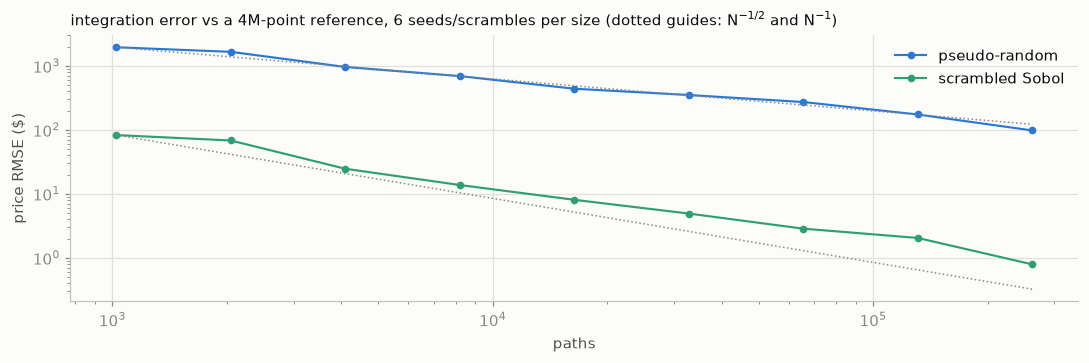

Sobol at 1,024 paths: RMSE $83 — already at the level of pseudo-random at 400k (s.e. $79)


In [10]:
ref = price_rainbow(marg_list, CORR, df_usd, n_paths=2**22, seed=123,
                    method="sobol")["pv"]
sizes = 2 ** np.arange(10, 19)
rmse = {"pseudo-random": [], "scrambled Sobol": []}
for n in sizes:
    for meth in rmse:
        errs = [price_rainbow(marg_list, CORR, df_usd, n_paths=int(n), seed=s,
                              method="sobol" if "Sobol" in meth else "pseudo")["pv"]
                - ref for s in range(6)]
        rmse[meth].append(float(np.sqrt(np.mean(np.square(errs)))))

fig, ax = plt.subplots(figsize=(10, 3.4))
for meth, c in zip(rmse, ("#2a78d6", "#2e9e77")):
    ax.loglog(sizes, rmse[meth], "o-", color=c, lw=1.4, ms=4, label=meth)
ax.loglog(sizes, rmse["pseudo-random"][0] * (sizes / sizes[0]) ** -0.5,
          ls=":", color=C_GRAY, lw=1.0)
ax.loglog(sizes, rmse["scrambled Sobol"][0] * (sizes / sizes[0]) ** -1.0,
          ls=":", color=C_GRAY, lw=1.0)
ax.set_xlabel("paths")
ax.set_ylabel("price RMSE ($)")
ax.legend()
ax.set_title("integration error vs a 4M-point reference, 6 seeds/scrambles per size "
             "(dotted guides: N$^{-1/2}$ and N$^{-1}$)", loc="left", fontsize=10)
plt.tight_layout()
plt.show()
print(f"Sobol at {sizes[0]:,} paths: RMSE ${rmse['scrambled Sobol'][0]:,.0f} — "
      f"already at the level of pseudo-random at 400k (s.e. ${se:,.0f})")

### And fully deterministic: conditioning + 2-D Gaussian quadrature

`price_rainbow_quad` removes sampling altogether. HSI is integrated out in closed
form conditional on the two copula normals — given $(z_1, z_2)$ the payoff is a call
spread in $P_{HSI}$ with shifted strikes, priced exactly as the integral of the
conditional survival curve on the marginal's own grid — and the remaining two
dimensions get Gauss–Hermite (outer normal) × Gauss–Legendre (inner, in
copula-uniform space) quadrature, with the inner integral **split at the rank kink**
$P_{SPX} = P_{SX5E}$ so every panel integrates a smooth function. 8,192 nodes
reproduce the 4-million-path Sobol reference to ~\$0.1 in well under a second, with
zero seed variance; 2,048 nodes already land within ~4bp of price. Convergence at
small node counts is algebraic rather than spectral — the piecewise-linear quantile
tables both engines share put micro-kinks everywhere — but the practical statement
stands: for two or three European underlyings, deterministic quadrature replaces
Monte Carlo outright. It stops generalizing exactly where the real book's exotics
start (path dependence, more assets), which is why the sampling engines above stay
the reference.

In [11]:
import time

sizes_q = (8, 16, 24, 32, 48, 64)
rows = []
for n in sizes_q:
    t0 = time.time()
    q = price_rainbow_quad(marg_list, CORR, df_usd, n_outer=n, n_inner=n)
    rows.append({"nodes": q["n_nodes"], "pv ($)": q["pv"],
                 "err vs 4M-Sobol ($)": q["pv"] - ref,
                 "time (ms)": 1e3 * (time.time() - t0)})
qt = pd.DataFrame(rows, index=pd.Index([f"{n} x 2x{n}" for n in sizes_q], name="rule"))
print(qt.round({"pv ($)": 2, "err vs 4M-Sobol ($)": 2, "time (ms)": 0}).to_string())
assert abs(rows[-1]["err vs 4M-Sobol ($)"]) < 1.0   # deterministic == MC, to $1

           nodes    pv ($)  err vs 4M-Sobol ($)  time (ms)
rule                                                      
8 x 2x8      128  52862.30              -148.22        9.0
16 x 2x16    512  52929.25               -81.27       25.0
24 x 2x24   1152  52970.14               -40.38       71.0
32 x 2x32   2048  52991.44               -19.08      105.0
48 x 2x48   4608  53008.80                -1.72      392.0
64 x 2x64   8192  53010.39                -0.13      583.0


**Seasoned options — the same test away from the sweet spot.** A fresh ATM option at
$\tau = 1$ is the friendliest case a pricer ever sees, so here is one fixed
5,000-node rule (n=50, ~350ms) on older vintages of the same structure: sold up to 11
months ago, performance-to-date folded into each leg (total performance $= g\cdot X$
with $g = S_{asof}/S_{sale}$, strikes staying in sale-date units — the
`perf_to_date` argument of both pricers), remaining TTM down to 0.11y, and the basket
pushed deep toward the cap (the Sep-2025 vintage is worth twice the fresh one).
Per vintage the table shows the quadrature error against a 4M-path Sobol reference
and how many pseudo-random / Sobol paths it takes to reach that same accuracy.
Quadrature stays within \$0.4–\$4.1 — **≤ 0.5bp of price on every vintage** — while
pseudo-random MC would need $10^8$–$10^{10}$ paths and Sobol 33k–262k+. Sub-dollar
rows are upper bounds (the reference itself resolves only ~\$0.1–0.2). One honest
note: at matched single-price accuracy Sobol is actually a few times *faster* in
wall-clock on CPU (paths are cheaper than nodes); the quadrature's edge is zero
variance — bump its inputs and the greeks come out noise-free — plus a fixed tensor
shape that batches perfectly.

In [12]:
rows = []
for lag in (0, 21, 63, 126, 189, 231):              # trading days since sale
    sale = spots.index[-1 - lag]
    tau = ((sale + pd.Timedelta(days=365)) - val).days / 365.0
    g = (spots.loc[val] / spots.loc[sale]).to_numpy()
    mrg = [implied_marginal(sds[n], idx[n], tau) for n in NAMES]
    dfr = float(sds["SPX"].discount(idx["SPX"], tau))
    ref_s = price_rainbow(mrg, CORR, dfr, n_paths=2**22, seed=123, method="sobol",
                          perf_to_date=g)
    q = price_rainbow_quad(mrg, CORR, dfr, n_outer=50, n_inner=50, perf_to_date=g)
    err = q["pv"] - ref_s["pv"]
    c = ref_s["se"] * np.sqrt(2**22)                # pseudo RMSE = c / sqrt(N)
    n_sob = next((2**k for k in range(10, 19) if np.sqrt(np.mean(np.square(
        [price_rainbow(mrg, CORR, dfr, n_paths=2**k, seed=s, method="sobol",
                       perf_to_date=g)["pv"] - ref_s["pv"] for s in range(5)])))
        <= abs(err)), None)
    rows.append({"tau (y)": tau, "perf-to-date S/E/H": "/".join(f"{x:.2f}" for x in g),
                 "pv ($)": q["pv"], "quad err ($)": err,
                 "pseudo to match": f"{(c / max(abs(err), 1e-9))**2 / 1e6:,.0f}M",
                 "sobol to match": f"{n_sob:,}" if n_sob else "> 262,144"})
seas = pd.DataFrame(rows, index=pd.Index(
    [str(spots.index[-1 - lag].date()) for lag in (0, 21, 63, 126, 189, 231)],
    name="sold"))
print("one 50 x 2x50 rule (5,000 nodes) across vintages:")
print(seas.round({"tau (y)": 2, "pv ($)": 0, "quad err ($)": 2}).to_string())

one 50 x 2x50 rule (5,000 nodes) across vintages:
            tau (y) perf-to-date S/E/H    pv ($)  quad err ($) pseudo to match sobol to match
sold                                                                                         
2026-07-31     1.00     1.00/1.00/1.00   53009.0         -1.07          2,195M        262,144
2026-07-02     0.92     1.00/1.00/1.12   60448.0         -0.38         17,935M      > 262,144
2026-05-05     0.76     1.03/1.08/1.00   67904.0          1.44          1,183M        262,144
2026-02-05     0.52     1.10/1.07/0.96   74702.0          4.06            136M         32,768
2025-11-06     0.27     1.11/1.13/0.98   88521.0         -3.95            107M         32,768
2025-09-09     0.11     1.15/1.18/1.00  108652.0          2.06            146M         32,768


The price menu below is the payoff-design story. Against **SPX alone**, the rainbow is
~14% cheaper at the same 100/112 strikes — the basket diversifies away vol *and* gives
up most of SPX's rich forward carry by mixing in two low-carry indices — so the same
~\$54k premium that buys a 100/**110** spread on SPX buys the rainbow capped at
**112**. That is exactly the "cheaper structure, wider cap" trade-off the contract was
designed around. The ranked 50/30 weights partially offset the cheapening: the rank
premium adds $0.1\,\mathbb{E}|P_{SPX}-P_{SX5E}|\approx 1.1$ performance points to
the expected basket, of which the capped spread monetizes about a quarter (~\$2.9k
over the plain 40/40/20 basket).

Correlation robustness, same seed: repricing under the daily-return matrix or bumping
every pairwise correlation by ±0.1/±0.2 moves the premium by **less than half a
percent**. The two correlation channels nearly cancel for a capped near-ATM spread —
higher ρ raises basket vol (more mass carried past 100%) but shrinks the best–worst
spread (rank premium fades) — so the constant-historical-ρ shortcut is benign *for
this payoff*, though not a general license.

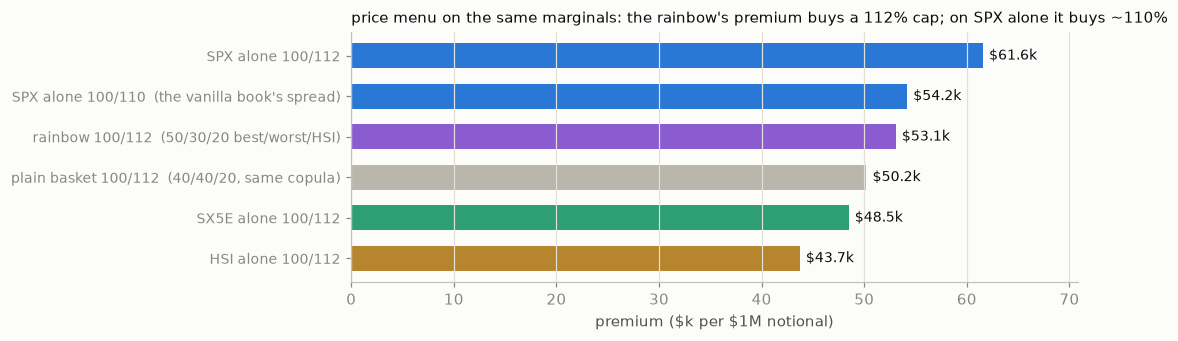

rank premium: +0.0106 expected basket performance, worth $2,853 inside the capped spread



correlation robustness (same paths through the copula):
                             pv vs base
5d corr (pricing base)  $53,074  +0.00%
daily corr              $52,758  -0.60%
all pairwise corr -0.2  $52,803  -0.51%
all pairwise corr -0.1  $52,973  -0.19%
all pairwise corr +0.1  $53,087  +0.02%
all pairwise corr +0.2  $52,956  -0.22%


In [13]:
menu = {
    "rainbow 100/112  (50/30/20 best/worst/HSI)": pv,
    "plain basket 100/112  (40/40/20, same copula)":
        df_usd * call_spread_payoff(0.4 * (perf[:, 0] + perf[:, 1])
                                    + 0.2 * perf[:, 2]).mean() * NOTIONAL,
    "SPX alone 100/110  (the vanilla book's spread)":
        marginal_call_spread(margs["SPX"], df_usd, k_hi=1.10) * NOTIONAL,
} | {f"{n} alone 100/112": marginal_call_spread(margs[n], df_usd) * NOTIONAL
     for n in NAMES}
tab = pd.Series(menu).sort_values()

fig, ax = plt.subplots(figsize=(10, 3.2))
row_color = lambda s: (C_BASKET if s.startswith("rainbow") else "#b9b7ac"
                       if s.startswith("plain") else C_IDX[s.split()[0]])
ax.barh(np.arange(len(tab)), tab.to_numpy() / 1e3,
        color=[row_color(s) for s in tab.index], height=0.62)
ax.bar_label(ax.containers[0], fmt="$%.1fk", padding=4, fontsize=9)
ax.set_yticks(np.arange(len(tab)), tab.index, fontsize=9)
ax.set_xlim(0, tab.max() / 1e3 * 1.15)
ax.set_xlabel(r"premium (\$k per \$1M notional)")
ax.grid(axis="y", visible=False)
ax.set_title("price menu on the same marginals: the rainbow's premium buys a 112% cap; "
             "on SPX alone it buys ~110%", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

rank_pts = 0.1 * np.abs(perf[:, 0] - perf[:, 1]).mean()
print(f"rank premium: +{rank_pts:.4f} expected basket performance, worth "
      f"${pv - tab['plain basket 100/112  (40/40/20, same copula)']:,.0f} "
      "inside the capped spread")

sens = {"5d corr (pricing base)": pv,
        "daily corr": price_rainbow(marg_list, mats["1d"], df_usd,
                                    n_paths=N_PATHS, seed=SEED)["pv"]}
off = ~np.eye(3, dtype=bool)
for d in (-0.2, -0.1, 0.1, 0.2):
    cm = CORR.to_numpy().copy()
    cm[off] = np.clip(cm[off] + d, -0.99, 0.99)
    sens[f"all pairwise corr {d:+.1f}"] = price_rainbow(
        marg_list, cm, df_usd, n_paths=N_PATHS, seed=SEED)["pv"]
sens = pd.Series(sens)
print("\ncorrelation robustness (same paths through the copula):")
print(pd.DataFrame({"pv": sens.map("${:,.0f}".format),
                    "vs base": (sens / pv - 1).map("{:+.2%}".format)}).to_string())

## 5. Round trip: the simulated vanillas re-imply the quoted smiles

The acceptance test of marginals + sampler together: price vanilla calls on each index
from the **same 400k simulated performances** the rainbow used, invert Black-76, and
lay the re-implied smile over the input. Two error levels, both printed below: the
construction itself (quadrature on the marginal's call curve, no sampling) round-trips
to **≤ 0.2bp of vol**, and the simulated vanillas deviate by ~3–13bp on average —
pure Monte-Carlo noise, largest out at the 60% wing where vega is dying so a fixed
price error costs many vol points (and shrinkable with the Sobol option above). What
the basket sees is the three markets' option-implied distributions, not an artifact
of the pipeline.

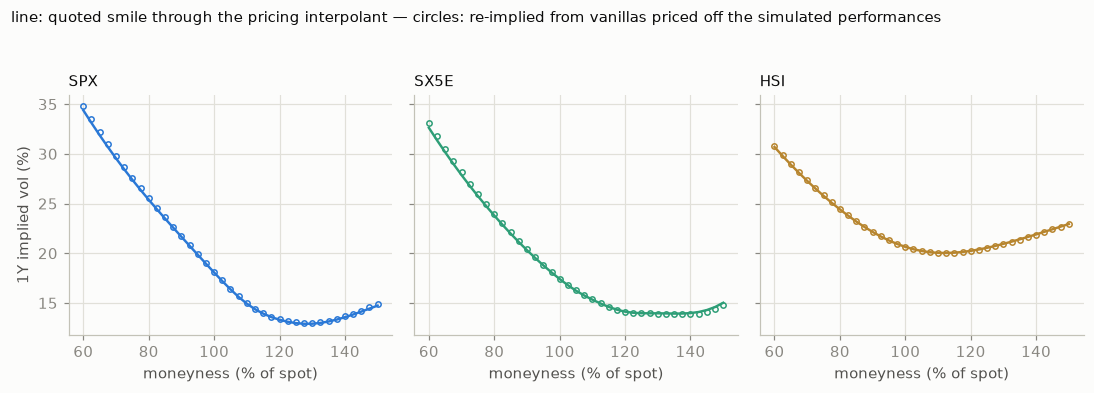

re-implied vs input smile, absolute error in vol bp:
                        SPX  SX5E   HSI
construction max (bp)   0.2   0.1   0.1
simulated mean (bp)    12.5  12.4   3.1
simulated max (bp)     40.9  46.3  10.0


In [14]:
ks = np.arange(0.60, 1.505, 0.025)
rows = {}
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey=True)
for ax, (n, m) in zip(axes, margs.items()):
    j = NAMES.index(n)
    mkt = 100 * np.interp(ks, m.x, m.vols)
    iv_mc = 100 * bs_implied_vol(
        np.maximum(perf[:, j][:, None] - ks[None, :], 0.0).mean(axis=0),
        m.fwd_ratio, ks, TTM)
    iv_qd = 100 * bs_implied_vol(np.interp(ks, m.x, m.call), m.fwd_ratio, ks, TTM)
    ax.plot(100 * ks, mkt, color=C_IDX[n], lw=1.6)
    ax.plot(100 * ks, iv_mc, "o", ms=3.5, color=C_IDX[n], mfc="none")
    ax.set_xlabel("moneyness (% of spot)")
    ax.set_title(n, loc="left", fontsize=10)
    rows[n] = {"construction max (bp)": np.nanmax(np.abs(iv_qd - mkt)) * 100,
               "simulated mean (bp)": np.nanmean(np.abs(iv_mc - mkt)) * 100,
               "simulated max (bp)": np.nanmax(np.abs(iv_mc - mkt)) * 100}
axes[0].set_ylabel("1Y implied vol (%)")
fig.suptitle("line: quoted smile through the pricing interpolant — circles: re-implied "
             "from vanillas priced off the simulated performances",
             x=0.01, ha="left", fontsize=10)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()
print("re-implied vs input smile, absolute error in vol bp:")
print(pd.DataFrame(rows).round(1).to_string())

## 6. The engine at book scale: batched quadrature on the GPU

Everything above prices one option. The roadmap doesn't: a daily-sold rainbow book is
~250 seasoned vintages per as-of date, attribution bumps that book input by input, and
the VaR study revalues it under thousands of scenarios — all embarrassingly parallel
batches of the same fixed-shape quadrature. `vol_pca/rainbow_torch.py` is that batch
engine: a `QuadBatch` stacks B problems (per-problem marginal tables, correlation
cholesky, discount, seasoning factors) into device tensors, and one
`price_quad_batch` call prices them all, CPU or GPU, chunked so the big
`(B, nodes, grid)` survival tensor never outgrows memory. Design choices, made for the
stages ahead:

- **Tables on CPU, integration on device.** Marginal construction is a fraction of a
  second per book and stays numpy/scipy — that seam is exactly where scenario engines
  plug in later (shock the surface → rebuild marginals → new batch, no engine change).
- **float32 where it's heavy, float64 where it's delicate.** Consumer GPUs run fp64 at
  1/64 rate, so the survival matrix and its trapezoid panels (the tensors that dominate
  time and memory) are fp32, while node placement, table interpolation and the
  cumulative-integral accumulation stay fp64. Measured cost of fp32 vs the numpy
  engine: **under a tenth of a cent per option**.
- **Differentiable end to end**, with the survival stage gradient-checkpointed so
  backward memory stays at one chunk regardless of book size — the next cell turns
  that into exact spot deltas for every vintage in one backward pass.
- **The numpy engine remains the canonical oracle**: `tests/test_rainbow_torch.py`
  pins the two together (float64 to ~1e-11, float32 to sub-cent), and nothing outside
  `rainbow_torch.py` imports torch.

`uv sync` installs the pinned CUDA build (`torch==2.12.0+cu130`, the version this
machine's other project verified) via the `gpu` dependency group by default. On this
laptop's RTX 4070 (8GB, fp32-first), the book below prices at ~4.5 ms per option —
65–75x the numpy loop across runs — and holds that rate on 2,000-problem VaR-shaped
sweeps.

In [15]:
import time
import torch

from vol_pca.rainbow_torch import QuadBatch, QuadProblem, price_quad_batch

N_BOOK = 250
t0 = time.time()
probs = []
for lag in range(N_BOOK):
    sale = spots.index[-1 - lag]
    tau = ((sale + pd.Timedelta(days=365)) - val).days / 365.0
    g = tuple((spots.loc[val] / spots.loc[sale]).to_numpy())
    mrg = tuple(implied_marginal(sds[n], idx[n], tau) for n in NAMES)
    probs.append(QuadProblem(mrg, CORR,
                             float(sds["SPX"].discount(idx["SPX"], tau)), g))
t_tab = time.time() - t0

t0 = time.time()
pv_np = np.array([price_rainbow_quad(list(p.marginals), p.corr, p.df,
                                     perf_to_date=p.perf_to_date)["pv"]
                  for p in probs])
t_np = time.time() - t0

def timed(dev):
    batch = QuadBatch.from_problems(probs, device=dev)
    price_quad_batch(batch)                     # warmup: CUDA context, allocator
    if dev == "cuda":
        torch.cuda.synchronize()
    t1 = time.time()
    pv_t = price_quad_batch(batch)
    if dev == "cuda":
        torch.cuda.synchronize()
    return time.time() - t1, np.abs(pv_t.cpu().numpy() - pv_np).max()

rows = {"numpy loop (canonical oracle)": (t_np, 0.0)}
for dev in ("cpu", "cuda") if torch.cuda.is_available() else ("cpu",):
    rows[f"torch {dev} batch, fp32 survival"] = timed(dev)

bench = pd.DataFrame({k: {"time (s)": t, "ms / price": 1e3 * t / N_BOOK,
                          "speedup": t_np / t, "max |diff| ($)": d}
                      for k, (t, d) in rows.items()}).T
print(f"the daily-sold book as of {val.date()}: {N_BOOK} vintages, "
      f"tau {tau:.2f}..1.00, marginal tables built once in {t_tab:.1f}s (CPU)")
print(bench.round(4).to_string())
assert bench["max |diff| ($)"].max() < 0.01     # engines agree to sub-cent

the daily-sold book as of 2026-07-31: 250 vintages, tau 0.04..1.00, marginal tables built once in 0.4s (CPU)
                                 time (s)  ms / price  speedup  max |diff| ($)
numpy loop (canonical oracle)     81.3848    325.5394   1.0000          0.0000
torch cpu batch, fp32 survival    16.8016     67.2065   4.8439          0.0003
torch cuda batch, fp32 survival    3.1580     12.6322  25.7707          0.0006


### Exact book deltas from one backward pass

The engine is differentiable, so the book's spot sensitivities need no extra
revaluations at all: one backward pass returns exact $\partial V/\partial g$ for
**every vintage and every index** simultaneously — no finite-difference truncation,
no bump-size tuning. A +1% spot move today scales that index's seasoning factor on
every vintage, so the vintage's delta is $0.01\,g\,\partial V/\partial g$. Below,
the book-level autograd deltas are checked against ±0.05% central bumps of the same
engine, and the per-vintage profile is the attribution teaser: young vintages carry
full call-spread delta, old ones have rallied into the cap and their delta has
decayed — the same strike-drift story the SPX vanilla book told, now visible per
underlying. Spot legs will come from autograd like this; vol-surface legs will come
from bumped-table revaluations (the project's formula-free philosophy) — both batched
through the identical engine.

whole-book spot deltas, option-value convention (the book is short these):
      autograd ($/+1%)  central bump ($/+1%)
SPX           417843.1              417841.1
SX5E          396478.9              396477.0
HSI           180641.6              180641.2
autograd: all 750 per-vintage deltas in one backward pass, 1390.6s; the six bumped revaluations behind the check column took 7.1s


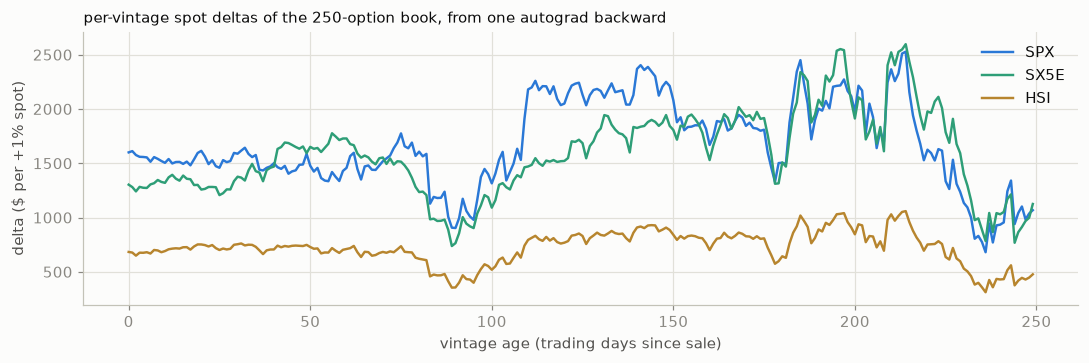

In [16]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
batch = QuadBatch.from_problems(probs, device=dev)
batch.g.requires_grad_(True)
t0 = time.time()
price_quad_batch(batch).sum().backward()
if dev == "cuda":
    torch.cuda.synchronize()
t_ad = time.time() - t0
delta = (0.01 * batch.g * batch.g.grad).detach().cpu().numpy()  # $ per +1%, vintage x index

def bumped(j, h):
    scale = np.where(np.arange(3) == j, 1.0 + h, 1.0)
    pb = [QuadProblem(p.marginals, p.corr, p.df,
                      tuple(np.asarray(p.perf_to_date) * scale)) for p in probs]
    return float(price_quad_batch(QuadBatch.from_problems(pb, device=dev)).sum())

t0 = time.time()
fd = np.array([(bumped(j, 5e-4) - bumped(j, -5e-4)) / 1e-3 * 0.01 for j in range(3)])
t_fd = time.time() - t0

comp = pd.DataFrame({"autograd ($/+1%)": delta.sum(axis=0),
                     "central bump ($/+1%)": fd}, index=NAMES)
print("whole-book spot deltas, option-value convention (the book is short these):")
print(comp.round(1).to_string())
print(f"autograd: all {delta.size} per-vintage deltas in one backward pass, {t_ad:.1f}s; "
      f"the six bumped revaluations behind the check column took {t_fd:.1f}s")

fig, ax = plt.subplots(figsize=(10, 3.4))
for j, n in enumerate(NAMES):
    ax.plot(np.arange(N_BOOK), delta[:, j], color=C_IDX[n], lw=1.6, label=n)
ax.set_xlabel("vintage age (trading days since sale)")
ax.set_ylabel("delta ($ per +1% spot)")
ax.legend()
ax.set_title("per-vintage spot deltas of the 250-option book, from one autograd backward",
             loc="left", fontsize=10)
plt.tight_layout()
plt.show()

### The sampler on the same batches: device-resident Sobol

The stochastic engine runs on the GPU too, over the very same `QuadBatch` tables
(built with `scores=False` — the sampler needs no normal-score tables), and it
replays the numpy sampler's math on identical normals to ~1e-11. The point sets
follow the common-random-numbers discipline the attribution needs: **one scrambled
Sobol set per book slot**, generated once with scipy (the numpy engine's generator)
and resident on the device — a vintage keeps its points for every day and every
component revaluation, so differences cancel the sampling noise, while independent
slot scrambles keep book-level errors averaging down like √slots instead of adding
coherently. The cell demonstrates both properties at the calibrated 2,048 paths
(≈\$100 per contract): per-contract deviations from the quadrature marks sit at the
calibrated ~\$50, and the book total lands well inside the √-rule. At ~20–25 µs per
option, a Sobol pass over the entire attribution history (~6M valuations) is two to
three minutes of GPU compute — the quadrature stays the deterministic engine of
record, and this sampler is its near-free cross-check and the future nested-VaR
workhorse.

In [17]:
from vol_pca.rainbow_torch import price_sobol_batch, sobol_normals

zsets = sobol_normals(len(probs), 2048, seed=1, device=dev)  # one scramble per slot
sob_batch = QuadBatch.from_problems(probs, device=dev, scores=False)
price_sobol_batch(sob_batch, zsets)                          # warmup
if dev == "cuda":
    torch.cuda.synchronize()
t0, reps = time.time(), 50
for _ in range(reps):
    pv_sob = price_sobol_batch(sob_batch, zsets)
if dev == "cuda":
    torch.cuda.synchronize()
ms_book = 1e3 * (time.time() - t0) / reps

d = pv_sob.cpu().numpy() - pv_np                             # vs 4,608-node quad marks
print(f"250-vintage book at 2,048 paths/slot: {ms_book:.1f} ms/book "
      f"= {1e3 * ms_book / len(probs):.0f} us per option "
      f"(numpy sampler: ~1.0 ms per option per CPU core)")
print(f"vs quadrature marks: per-contract std ${d.std():,.0f} (calibrated ~$50), "
      f"max |diff| ${np.abs(d).max():,.0f}")
print(f"book-total difference ${d.sum():+,.0f}, sqrt-rule scale "
      f"+-${d.std() * np.sqrt(len(probs)):,.0f} — slot scrambles keep book noise averaging down")
assert np.abs(d).max() < 500 and abs(d.sum()) < 3000

250-vintage book at 2,048 paths/slot: 4.2 ms/book = 17 us per option (numpy sampler: ~1.0 ms per option per CPU core)
vs quadrature marks: per-contract std $41 (calibrated ~$50), max |diff| $178
book-total difference $-324, sqrt-rule scale +-$648 — slot scrambles keep book noise averaging down


## Caveats, and where this goes next

- **The Gaussian copula has zero tail dependence**: joint crashes are underweighted
  relative to equity markets, which flatters exactly the states where the 30%
  worst-of weight bites. A Student-t copula (one extra parameter) is the natural next
  dial; the marginals and machinery would not change.
- **Historical (P-measure) correlation prices a Q-measure product.** Nothing in this
  dataset carries implied correlation, so this is forced; the ±0.2 robustness above is
  the honest error bar, and for this payoff it is small.
- **No quanto adjustment, per spec**: a USD-settled payoff on SX5E/HSI strictly shifts
  each non-USD forward by $-\rho_{FX,idx}\,\sigma_{FX}\,\sigma_{idx}\,T$ — a
  drift correction this data cannot calibrate, deliberately ignored alongside FX risk.
- **Wing treatment is documented, not invisible**: the tapered-slope extrapolation
  keeps each recovered mean within a basis point of its forward and residual
  negative-density mass at ~1e-4 — irrelevant three σ below the strikes, but it is a
  modeling choice, and a different taper would slightly reprice the far worst-of tail.
- **Next**: sell one rainbow per day (the SPX book's protocol) to build a steady-state
  rainbow book; attribute its P&L across three surfaces and the correlation input;
  then the project's central question again — bump-based greeks VaR (now also per
  surface, plus a correlation exposure) versus full nested-MC revaluation, where each
  scenario's revaluation is itself a Monte Carlo. That last comparison is the real
  book's cost problem in miniature, and the reason this valuation was built
  simulation-first. Section 6's batched GPU engine is what makes the expensive
  baseline affordable — a full 3,138-scenario × 250-vintage revaluation projects to
  about an hour on this machine — and the same batches will serve the bumped greeks.